In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Load the data
df = pd.read_csv('orders_data.csv')

df.head()


,Order Id,Order Date,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub Category,Product Id,cost price,List Price,Quantity,Discount Percent
0,1,01-03-2023,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,FUR-BO-10001798,240,260,2,2
1,2,15-08-2023,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,FUR-CH-10000454,600,730,3,3
2,3,10-01-2023,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,OFF-LA-10000240,10,10,2,5
3,4,18-06-2022,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,FUR-TA-10000577,780,960,5,2
4,5,13-07-2022,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,OFF-ST-10000760,20,20,2,5


### Fixing ship mode column

In [2]:
df['Ship Mode'].unique()

array(['Second Class', 'Standard Class', 'Not Available', 'unknown',
       'First Class', nan, 'Same Day'], dtype=object)

In [3]:
df = pd.read_csv('orders_data.csv', na_values=['Not Available', 'unknown'])
df['Ship Mode'].unique()

array(['Second Class', 'Standard Class', nan, 'First Class', 'Same Day'],
      dtype=object)

In [4]:
# converting Date column to date object 
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d-%m-%Y', errors='coerce')


# EDA

In [5]:
# 1. Basic info
print(df.info())  # Data types, non-null counts

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Order Id          9994 non-null   int64         
 1   Order Date        9994 non-null   datetime64[ns]
 2   Ship Mode         9988 non-null   object        
 3   Segment           9994 non-null   object        
 4   Country           9994 non-null   object        
 5   City              9994 non-null   object        
 6   State             9994 non-null   object        
 7   Postal Code       9994 non-null   int64         
 8   Region            9994 non-null   object        
 9   Category          9994 non-null   object        
 10  Sub Category      9994 non-null   object        
 11  Product Id        9994 non-null   object        
 12  cost price        9994 non-null   int64         
 13  List Price        9994 non-null   int64         
 14  Quantity          9994 n

In [6]:
# Fill missing Ship Mode with 'Unknown'
df['Ship Mode'] = df['Ship Mode'].fillna('Unknown')

print(df['Ship Mode'].value_counts(dropna=False))


Ship Mode
Standard Class    5962
Second Class      1945
First Class       1538
Same Day           543
Unknown              6
Name: count, dtype: int64


In [7]:
# Check for duplicate rows
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

# If there are duplicates, you can remove them:
# df = df.drop_duplicates()


Number of duplicate rows: 0


In [8]:
# Summary statistics for numerical columns
df.describe()


,Order Id,Order Date,Postal Code,cost price,List Price,Quantity,Discount Percent
count,9994.000000,9994,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2022-12-29 10:20:34.820892672,55190.379428,201.189714,229.756854,3.789574,3.484090
min,1.000000,2022-01-01 00:00:00,1040.000000,0.000000,0.000000,1.000000,2.000000
25%,2499.250000,2022-06-29 00:00:00,23223.000000,20.000000,20.000000,2.000000,2.000000
50%,4997.500000,2022-12-28 00:00:00,56430.500000,50.000000,50.000000,3.000000,3.000000
75%,7495.750000,2023-07-03 00:00:00,90008.000000,180.000000,210.000000,5.000000,4.000000
max,9994.000000,2023-12-31 00:00:00,99301.000000,18110.000000,22640.000000,14.000000,5.000000
std,2885.163629,NaN,32063.693350,537.743203,623.245839,2.225110,1.114211


## 1. Investigate zero cost and list prices:

In [9]:
# Orders with zero cost price
zero_cost = df[df['cost price'] == 0]
print(f"Orders with zero cost price: {len(zero_cost)}")

# Orders with zero list price
zero_list = df[df['List Price'] == 0]
print(f"Orders with zero list price: {len(zero_list)}")


Orders with zero cost price: 507
Orders with zero list price: 507


In [10]:
# Find orders where both cost price and list price are zero
zero_cost_and_list = df[(df['cost price'] == 0) & (df['List Price'] == 0)]

# How many such orders?
zero_cost_and_list_count = len(zero_cost_and_list)
print(f"Orders with both zero cost and zero list price: {zero_cost_and_list_count}")

# What percentage of the dataset is this?
percentage_zero_cost_and_list = (zero_cost_and_list_count / len(df)) * 100
print(f"Percentage of such orders: {percentage_zero_cost_and_list:.2f}%")

# zero_cost_and_list.shape -> 507,16
zero_cost_and_list.head()


Orders with both zero cost and zero list price: 507
Percentage of such orders: 5.07%


,Order Id,Order Date,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub Category,Product Id,cost price,List Price,Quantity,Discount Percent
15,16,2022-06-18,Standard Class,Home Office,United States,Fort Worth,Texas,76106,Central,Office Supplies,Binders,OFF-BI-10000756,0,0,3,5
30,31,2022-11-20,Standard Class,Consumer,United States,Philadelphia,Pennsylvania,19140,East,Office Supplies,Envelopes,OFF-EN-10001509,0,0,2,5
61,62,2023-04-08,First Class,Consumer,United States,Troy,New York,12180,East,Office Supplies,Art,OFF-AR-10001868,0,0,1,5
70,71,2022-11-29,Standard Class,Consumer,United States,New York City,New York,10009,East,Office Supplies,Binders,OFF-BI-10004654,0,0,1,3
75,76,2023-04-17,First Class,Corporate,United States,Houston,Texas,77041,Central,Office Supplies,Binders,OFF-BI-10004182,0,0,3,4


Found that 507 orders (5.07% of data) have both cost price and list price as zero.
Discounts on $0 prices are invalid.

In [11]:
# Remove orders with both zero cost and zero list price
df = df[~((df['cost price'] == 0) & (df['List Price'] == 0))]

# Document the cleaning step
print("Removed 507 orders (5.07%) with both cost price and list price as zero. These are likely data errors or test records.")
print(f"Dataset now has {len(df)} rows.")


Removed 507 orders (5.07%) with both cost price and list price as zero. These are likely data errors or test records.
Dataset now has 9487 rows.


## 2. Check for outliers:

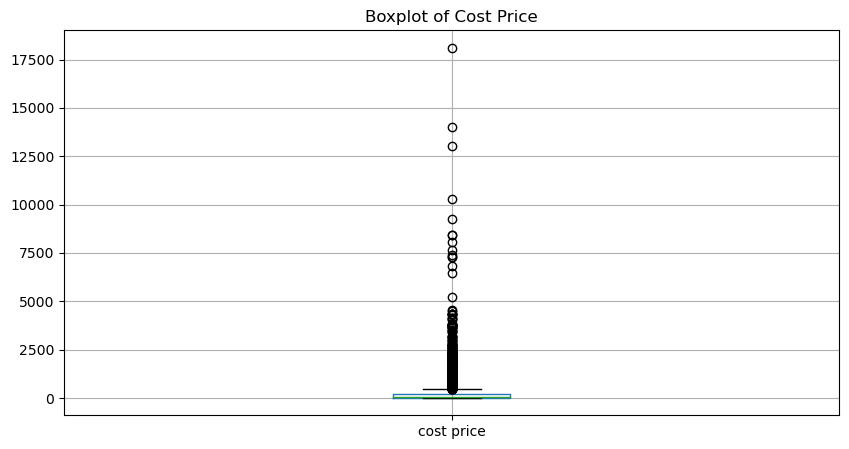

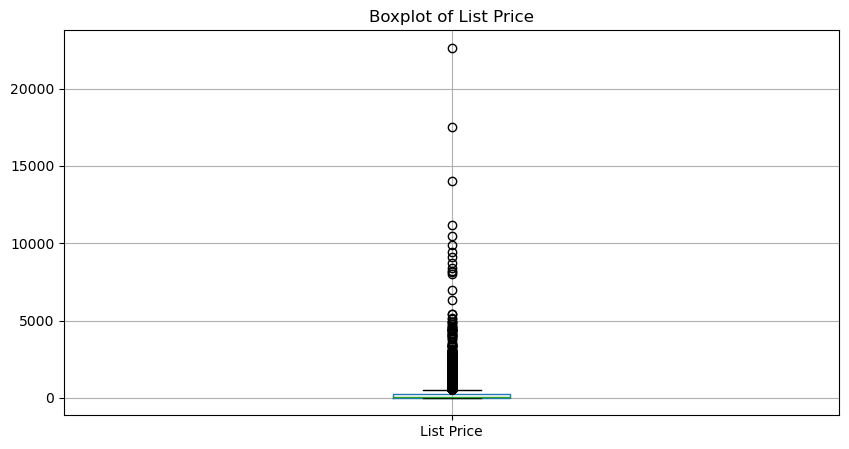

In [12]:
import matplotlib.pyplot as plt

# Boxplot for cost price
plt.figure(figsize=(10, 5))
df.boxplot(column='cost price')
plt.title('Boxplot of Cost Price')
plt.show()

# Boxplot for list price
plt.figure(figsize=(10, 5))
df.boxplot(column='List Price')
plt.title('Boxplot of List Price')
plt.show()


In [13]:
# Identifying and Segmenting Outliers
import seaborn as sns

# df is your cleaned dataframe (with zero prices removed)
# Define IQR for List Price
Q1 = df['List Price'].quantile(0.25)
Q3 = df['List Price'].quantile(0.75)
IQR = Q3 - Q1

# Define outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Segment the data
main_cluster = df[(df['List Price'] >= lower_bound) & (df['List Price'] <= upper_bound)]
outliers = df[(df['List Price'] < lower_bound) | (df['List Price'] > upper_bound)]

# Calculate percentages
main_percentage = len(main_cluster) / len(df) * 100
outlier_percentage = len(outliers) / len(df) * 100

print(f"Main cluster: {len(main_cluster)} orders ({main_percentage:.2f}%)")
print(f"Outliers: {len(outliers)} orders ({outlier_percentage:.2f}%)")


Main cluster: 8428 orders (88.84%)
Outliers: 1059 orders (11.16%)


In [14]:
# Compare product categories in main cluster vs. outliers
main_categories = main_cluster['Category'].value_counts(normalize=True).mul(100).round(1)
outlier_categories = outliers['Category'].value_counts(normalize=True).mul(100).round(1)

# Create a comparison table
category_comparison = pd.DataFrame({
    'Main Cluster (%)': main_categories,
    'Outliers (%)': outlier_categories
}).fillna(0)

# print("\nProduct Category Comparison:")
print("\nPercentage of orders belong to each product category in the main cluster vs. outliers: ")

display(category_comparison)



Percentage of orders belong to each product category in the main cluster vs. outliers: 


,Main Cluster (%),Outliers (%)
Category,,
Furniture,19.9,39.6
Office Supplies,62.8,25.3
Technology,17.4,35.1


* Furniture: 39.6% of outliers vs. 19.9% in main cluster → 2x more common in high-value orders.
* Office supplies are frequent but low-value purchases and are rarely appear in high-value orders.
* Technology: 35.1% vs. 17.4% → 2x more common in high-value orders.


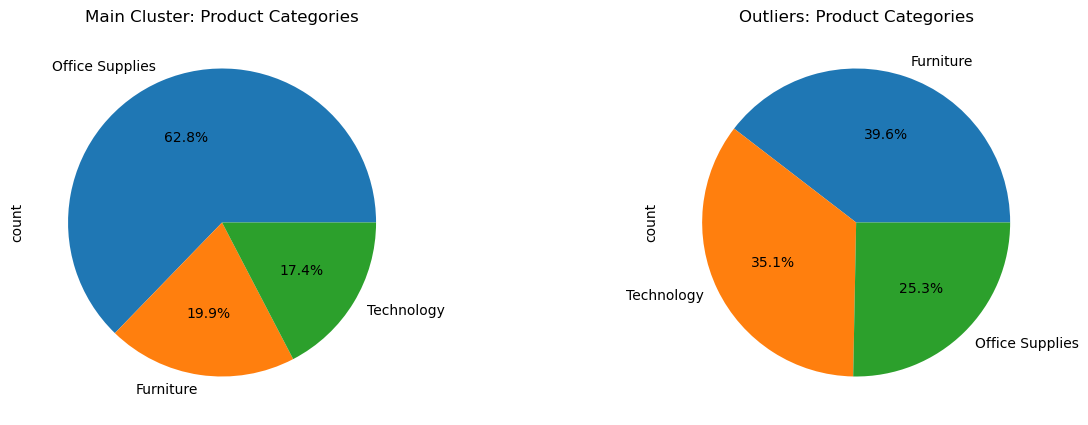

In [15]:
# Plot comparison of product categories
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Main cluster categories
main_cluster['Category'].value_counts().plot.pie(autopct='%1.1f%%', ax=ax[0])
ax[0].set_title('Main Cluster: Product Categories')

# Outlier categories
outliers['Category'].value_counts().plot.pie(autopct='%1.1f%%', ax=ax[1])
ax[1].set_title('Outliers: Product Categories')

plt.show()


## Compare Profit Margins between Main vs Outlier

In [16]:
def calculate_profit(df):
    df['Profit'] = ((df['List Price'] * (1 - df['Discount Percent']/100) - df['cost price']) * df['Quantity'])
    return df

main_cluster = calculate_profit(main_cluster)
outliers = calculate_profit(outliers)

# Profitability comparison
profit_comparison = pd.DataFrame({
    'Main Cluster': [
        main_cluster['Profit'].mean(),
        main_cluster['Profit'].median(),
        (main_cluster['Profit'] < 0).mean()*100
    ],
    'Outliers': [
        outliers['Profit'].mean(),
        outliers['Profit'].median(),
        (outliers['Profit'] < 0).mean()*100
    ]
}, index=['Average Profit', 'Median Profit', '% Loss-Making Orders']).round(2)

print("Profitability Comparison:")
display(profit_comparison)


Profitability Comparison:


C:\Users\KIIT\AppData\Local\Temp\ipykernel_5580\2956754813.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Profit'] = ((df['List Price'] * (1 - df['Discount Percent']/100) - df['cost price']) * df['Quantity'])
C:\Users\KIIT\AppData\Local\Temp\ipykernel_5580\2956754813.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Profit'] = ((df['List Price'] * (1 - df['Discount Percent']/100) - df['cost price']) * df['Quantity'])


,Main Cluster,Outliers
Average Profit,36.02,695.37
Median Profit,8.50,365.00
% Loss-Making Orders,47.29,1.04


* Average Profit: Outliers generates 695.37, 19.3x higher profit per order than typical orders 36.02.

* Median Profit: outlier orders 365.00, 42.9x higher median profit than typical orders 8.50

* Loss-Making Orders: Nearly half (47.29%) typical orders generate losses, compared to just 1.04% of outlier orders

* Insight: The outlier cluster represents premium, high-profit business segment with significantly better profitability metrics and almost no loss-making transactions.


## Customer Segment Analysis between Main vs Outlier


Customer Segment Comparison:


,Main Cluster,Outliers
Segment,,
Consumer,52.3,48.7
Corporate,30.0,32.9
Home Office,17.8,18.4


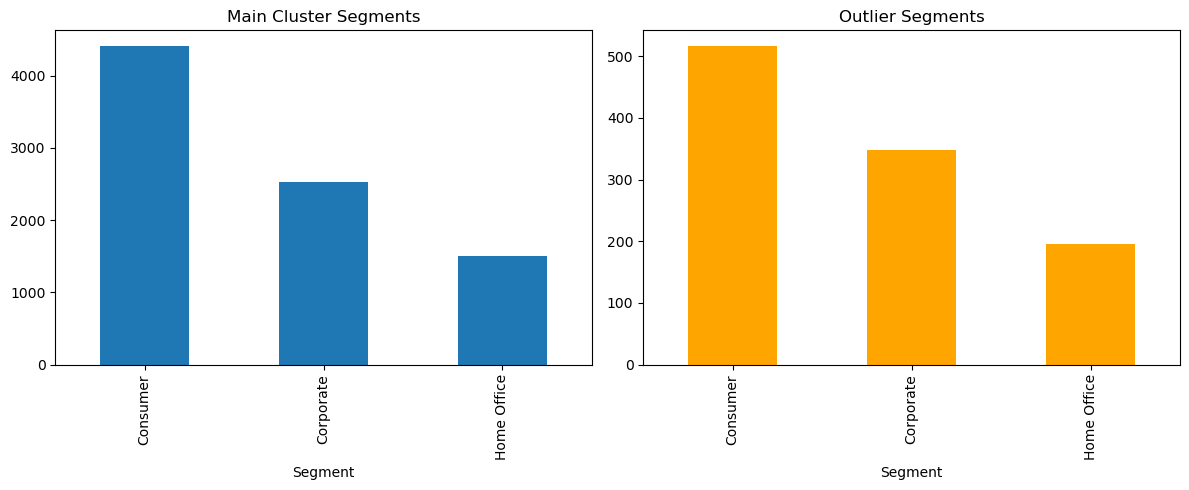

In [17]:
def segment_analysis(df):
    return df['Segment'].value_counts(normalize=True).mul(100).round(1)

segment_comparison = pd.DataFrame({
    'Main Cluster': segment_analysis(main_cluster),
    'Outliers': segment_analysis(outliers)
})

print("\nCustomer Segment Comparison:")
display(segment_comparison)


# Visualization
fig, ax = plt.subplots(1, 2, figsize=(12,5))
main_cluster['Segment'].value_counts().plot(kind='bar', ax=ax[0], title='Main Cluster Segments')
outliers['Segment'].value_counts().plot(kind='bar', ax=ax[1], title='Outlier Segments', color='orange')
plt.tight_layout()
plt.show()


* Almost identical in both main and outlier clusters
* Consumers have the highest margin

## Geographic Analysis between Main vs Outlier(Religion)

In [18]:
def region_analysis(df):
    regional = df.groupby('Region').agg(
        Total_Orders=('Order Id', 'count'),
        Avg_Order_Value=('List Price', 'mean'),
        Total_Profit=('Profit', 'sum')
    )
    regional['Pct_Orders'] = (regional['Total_Orders'] / len(df)) * 100
    return regional.round(2)
# Pct_Orders - percentage of orders coming from each region

regional_main = region_analysis(main_cluster)
regional_outliers = region_analysis(outliers)

print("Main Cluster Regional Performance:")
display(regional_main)
print("\nOutlier Regional Performance:")
display(regional_outliers)


Main Cluster Regional Performance:


,Total_Orders,Avg_Order_Value,Total_Profit,Pct_Orders
Region,,,,
Central,1918,103.74,66605.4,22.76
East,2407,102.75,86373.1,28.56
South,1342,102.99,48011.9,15.92
West,2761,105.31,102544.1,32.76



Outlier Regional Performance:


,Total_Orders,Avg_Order_Value,Total_Profit,Pct_Orders
Region,,,,
Central,227,1330.79,169515.8,21.44
East,306,1408.69,209400.7,28.90
South,181,1399.50,154731.7,17.09
West,345,1259.33,202745.5,32.58


###  Geographic Analysis between Main vs Outlier(Religion,Country, State, City)

In [19]:
def detailed_location_analysis(df):
    # Group by multiple location columns
    location_cols = ['State', 'City', 'Region']  
    
    regional = df.groupby(location_cols).agg(
        Total_Orders=('Order Id', 'count'),
        Avg_Order_Value=('List Price', 'mean'),
        Total_Profit=('Profit', 'sum')
    )
    
    # Calculate percentage of orders
    regional['Pct_Orders'] = (regional['Total_Orders'] / len(df)) * 100
    
    # Calculate profit per order
    regional['Profit_Per_Order'] = regional['Total_Profit'] / regional['Total_Orders']
    
    return regional.round(2)

# Run detailed location analysis
regional_main_detailed = detailed_location_analysis(main_cluster)
regional_outliers_detailed = detailed_location_analysis(outliers)

# Display top 10 cities by order count for main cluster
print("Top 10 Locations by Order Count (Main Cluster):")
display(regional_main_detailed.sort_values('Total_Orders', ascending=False).head(10))

# Display top 10 cities by order count for outlier cluster
print("Top 10 Locations by Order Count (outlier Cluster):")
display(regional_outliers_detailed.sort_values('Total_Orders', ascending=False).head(10))

# Display top 10 cities by profit for outliers
print("\nTop 10 Locations by Profit (Outliers):")
display(regional_outliers_detailed.sort_values('Total_Profit', ascending=False).head(10))

# Display top 10 cities by profit for main cluster
print("\nTop 10 Locations by Profit (Outliers):")
display(regional_main_detailed.sort_values('Total_Profit', ascending=False).head(10))

# Display summary by Region (main)
print("\nSummary by Region (Main Cluster):")
display(regional_main_detailed.groupby('Region').agg({
    'Total_Orders': 'sum',
    'Total_Profit': 'sum',
    'Avg_Order_Value': 'mean'
}).sort_values('Total_Orders', ascending=False))

# Display summary by Region (outlier)
print("\nSummary by Region (Main Cluster):")
display(regional_outliers_detailed.groupby('Region').agg({
    'Total_Orders': 'sum',
    'Total_Profit': 'sum',
    'Avg_Order_Value': 'mean'
}).sort_values('Total_Orders', ascending=False))


Top 10 Locations by Order Count (Main Cluster):


Total_Orders  Avg_Order_Value  \
State        City          Region                                   
New York     New York City East              767           101.43   
California   Los Angeles   West              652           109.83   
             San Francisco West              443            88.74   
Pennsylvania Philadelphia  East              442           103.28   
Washington   Seattle       West              366           103.74   
Texas        Houston       Central           300            91.50   
Illinois     Chicago       Central           260            91.54   
California   San Diego     West              140           113.71   
Texas        Dallas        Central           129            94.19   
Ohio         Columbus      East              105            88.95   

                                    Total_Profit  Pct_Orders  Profit_Per_Order  
State        City          Region                                               
New York     New York City East          26697.3        9.10             34.81  
California   Los Angeles   West          27059.3        7.74             41.50  
             San Francisco West          13205.1        5.26             29.81  
Pennsylvania Philadelphia  East          16756.0        5.24             37.91  
Washington   Seattle       West          12918.7        4.34             35.30  
Texas        Houston       Central        9419.9        3.56             31.40  
Illinois     Chicago       Central        7999.8        3.08             30.77  
California   San Diego     West           5197.0        1.66             37.12  
Texas        Dallas        Central        2842.2        1.53             22.03  
Ohio         Columbus      East           3546.7        1.25             33.78

Top 10 Locations by Order Count (outlier Cluster):


Total_Orders  Avg_Order_Value  \
State        City          Region                                   
New York     New York City East              121          1474.38   
California   Los Angeles   West               86          1211.74   
             San Francisco West               55          1334.18   
Washington   Seattle       West               52          1567.69   
Pennsylvania Philadelphia  East               47          1346.17   
Texas        Houston       Central            34          1090.88   
California   San Diego     West               27          1168.15   
Illinois     Chicago       Central            22          1123.18   
Michigan     Detroit       Central            13          2053.08   
Florida      Jacksonville  South              11          3148.18   

                                    Total_Profit  Pct_Orders  Profit_Per_Order  
State        City          Region                                               
New York     New York City East          77155.3       11.43            637.65  
California   Los Angeles   West          46235.5        8.12            537.62  
             San Francisco West          35267.5        5.19            641.23  
Washington   Seattle       West          37847.0        4.91            727.83  
Pennsylvania Philadelphia  East          35863.3        4.44            763.05  
Texas        Houston       Central       18563.0        3.21            545.97  
California   San Diego     West          16201.4        2.55            600.05  
Illinois     Chicago       Central       11519.4        2.08            523.61  
Michigan     Detroit       Central       18902.7        1.23           1454.05  
Florida      Jacksonville  South         26398.1        1.04           2399.83


Top 10 Locations by Profit (Outliers):


...

,,,Total_Orders,Avg_Order_Value,Total_Profit,Pct_Orders,Profit_Per_Order
State,City,Region,,,,,
California,Los Angeles,West,652,109.83,27059.3,7.74,41.50
New York,New York City,East,767,101.43,26697.3,9.10,34.81
Pennsylvania,Philadelphia,East,442,103.28,16756.0,5.24,37.91
California,San Francisco,West,443,88.74,13205.1,5.26,29.81
Washington,Seattle,West,366,103.74,12918.7,4.34,35.30
Texas,Houston,Central,300,91.50,9419.9,3.56,31.40
Illinois,Chicago,Central,260,91.54,7999.8,3.08,30.77
Michigan,Detroit,Central,99,158.69,5910.4,1.17,59.70
California,San Diego,West,140,113.71,5197.0,1.66,37.12



Summary by Region (Main Cluster):


,Total_Orders,Total_Profit,Avg_Order_Value
Region,,,
West,2761,102544.1,112.727818
East,2407,86373.1,99.629646
Central,1918,66605.4,105.363115
South,1342,48011.9,99.982344



Summary by Region (Main Cluster):


,Total_Orders,Total_Profit,Avg_Order_Value
Region,,,
West,345,202745.5,1136.587901
East,306,209400.7,1287.250794
Central,227,169515.8,1279.501757
South,181,154731.7,1289.424429


* Top Urban Centers: New York City, Los Angeles, and San Francisco appear in top 5 for both main and outlier orders

* Major cities dominate order volume, but some smaller cities (Lafayette, Jacksonville, Detroit) lead in profit per order.

* Profit Powerhouses: Some locations show extraordinary profit potential:
* Lafayette, IN: 7,470.50 profit per order (highest in dataset)
* Jacksonville, FL: 2,399.83 profit per order
* Detroit, MI: 1,454.05 profit per order

* Key Insight: While major cities generate high volume, certain smaller markets produce exceptional per-order profitability.

<!-- # Top Urban Centers: New York City, Los Angeles, and San Francisco appear in top 5 for both main and outlier orders

# Some locations show extraordinary profit potential:

# Lafayette, IN: $7,470.50 profit per order (highest in dataset)

# Jacksonville, FL: $2,399.83 profit per order

# Detroit, MI: $1,454.05 profit per order

# Key Insight: While major cities generate high volume, certain smaller markets produce exceptional per-order profitability.
 -->

<!-- Key Insight: The East region has the highest average order value for outliers $1,408.69, while maintaining similar distribution to typical orders.

* City-Level Analysis:
Top Urban Centers: New York City, Los Angeles, and San Francisco appear in top 5 for both main and outlier orders.
Some locations show extraordinary profit potential: 
1.Jacksonville, FL: $2,399.83 profit per order
2.Lafayette, IN: $7,470.50 profit per order (highest in dataset)
3.Detroit, MI: $1,454.05 profit per order

Key Insight: While major cities generate high volume, certain smaller markets produce exceptional per-order profitability.
 -->

## Time Series Analysis between Main vs Outlier(ns)

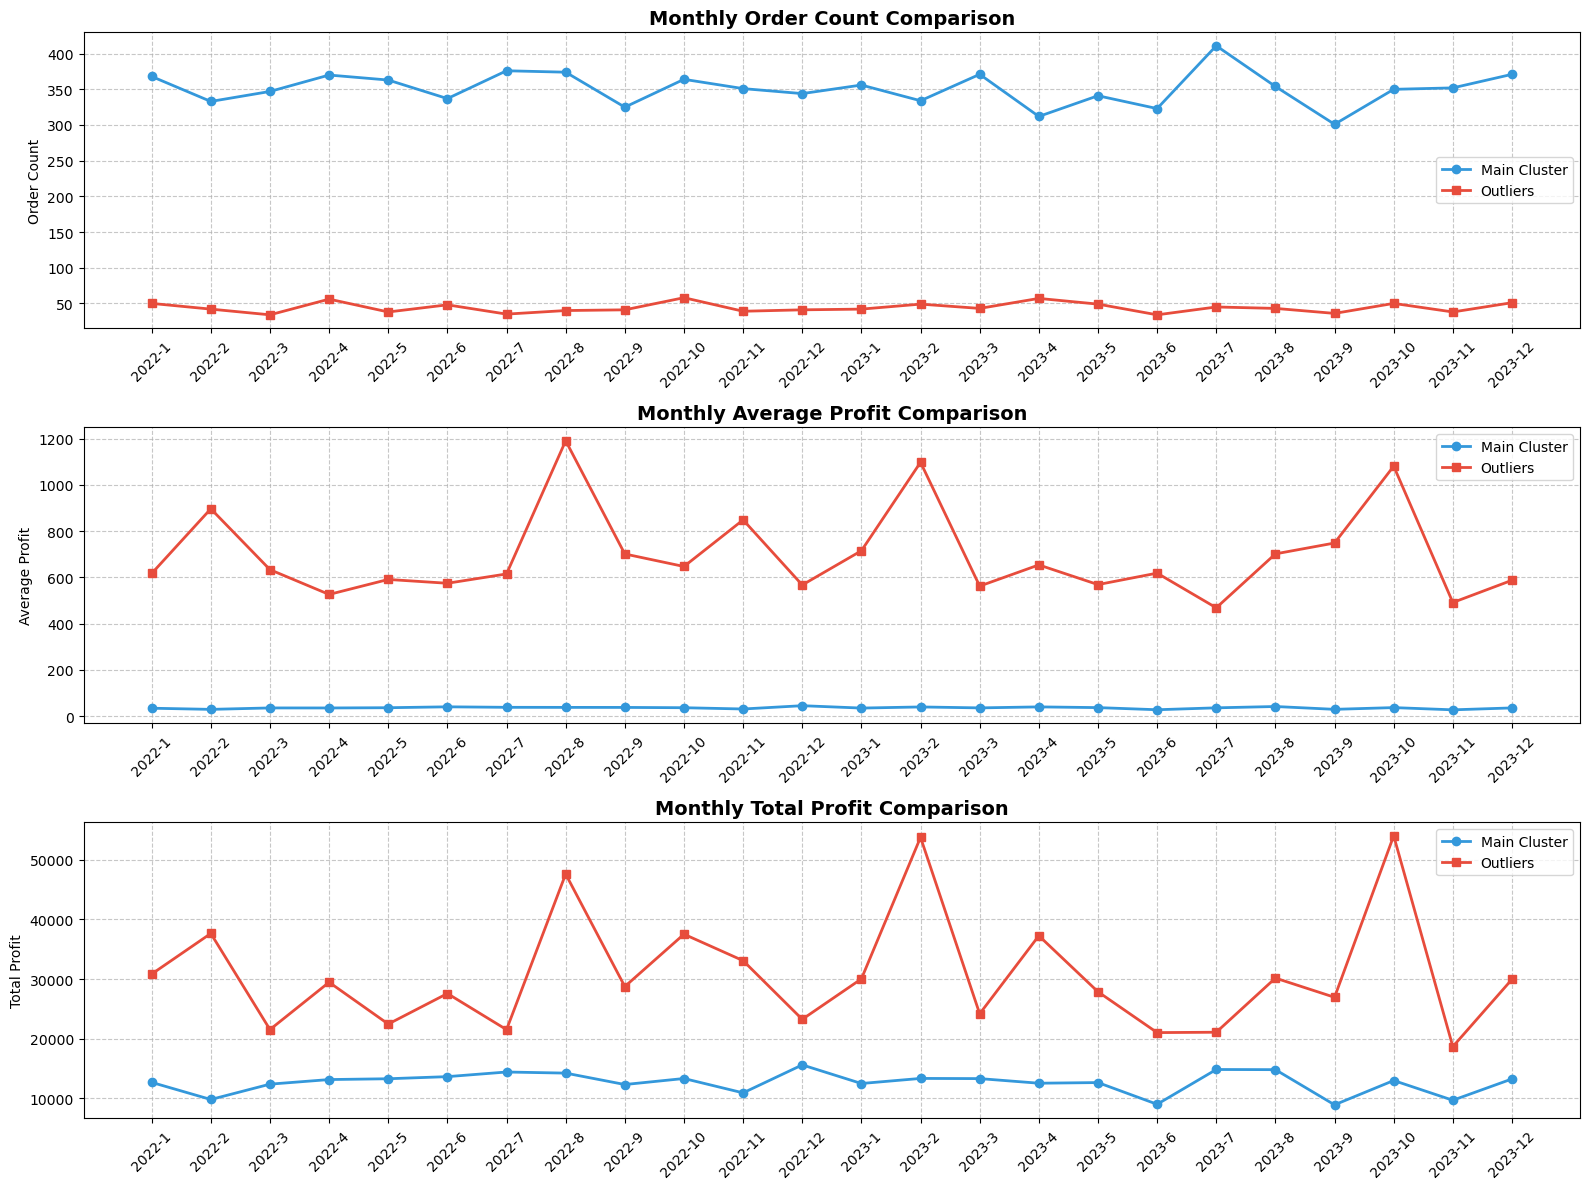

Time Analysis Completed - Data Trends Available in main_trends and outlier_trends variables


In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Time Series Analysis Function
def time_analysis(df):
    df = df.copy()
    # Ensure Order Date is in datetime format
    df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')
    
    # Extract year and month for grouping
    df['Month'] = df['Order Date'].dt.month
    df['Year'] = df['Order Date'].dt.year
    
    # Group by year and month to analyze trends
    time_trends = df.groupby(['Year', 'Month']).agg(
        Order_Count=('Order Id', 'count'),
        Avg_Profit=('Profit', 'mean'),
        Total_Profit=('Profit', 'sum')
    ).reset_index()
    
    return time_trends

# Execute time analysis for both clusters
main_trends = time_analysis(main_cluster)
outlier_trends = time_analysis(outliers)

# Plot time series comparison
plt.figure(figsize=(16, 12))

# Plot 1: Monthly Order Count Comparison
plt.subplot(3, 1, 1)
plt.plot(main_trends['Year'].astype(str) + '-' + main_trends['Month'].astype(str), 
         main_trends['Order_Count'], 
         marker='o', 
         linewidth=2,
         color='#3498db', 
         label='Main Cluster')
plt.plot(outlier_trends['Year'].astype(str) + '-' + outlier_trends['Month'].astype(str), 
         outlier_trends['Order_Count'], 
         marker='s', 
         linewidth=2,
         color='#e74c3c', 
         label='Outliers')
plt.title('Monthly Order Count Comparison', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.ylabel('Order Count')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

# Plot 2: Monthly Average Profit Comparison
plt.subplot(3, 1, 2)
plt.plot(main_trends['Year'].astype(str) + '-' + main_trends['Month'].astype(str), 
         main_trends['Avg_Profit'], 
         marker='o', 
         linewidth=2,
         color='#3498db', 
         label='Main Cluster')
plt.plot(outlier_trends['Year'].astype(str) + '-' + outlier_trends['Month'].astype(str), 
         outlier_trends['Avg_Profit'], 
         marker='s', 
         linewidth=2,
         color='#e74c3c', 
         label='Outliers')
plt.title('Monthly Average Profit Comparison', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.ylabel('Average Profit')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

# Plot 3: Monthly Total Profit Comparison
plt.subplot(3, 1, 3)
plt.plot(main_trends['Year'].astype(str) + '-' + main_trends['Month'].astype(str), 
         main_trends['Total_Profit'], 
         marker='o', 
         linewidth=2,
         color='#3498db', 
         label='Main Cluster')
plt.plot(outlier_trends['Year'].astype(str) + '-' + outlier_trends['Month'].astype(str), 
         outlier_trends['Total_Profit'], 
         marker='s', 
         linewidth=2,
         color='#e74c3c', 
         label='Outliers')
plt.title('Monthly Total Profit Comparison', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.ylabel('Total Profit')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

plt.tight_layout()
plt.savefig('monthly_trends.png', dpi=300)
plt.show()

# Return the dataframes for further analysis
print("Time Analysis Completed - Data Trends Available in main_trends and outlier_trends variables")


## Product Category × Subcategory between Main vs Outlier

Top 10 Subcategories by Outlier Average Profit:
           Category Sub Category  Main Cluster Avg Profit  \
15       Technology     Machines                70.540385   
14       Technology      Copiers                61.250000   
5   Office Supplies          Art                13.236648   
6   Office Supplies      Binders                19.513130   
12  Office Supplies     Supplies                13.438690   
7   Office Supplies    Envelopes                21.793852   
4   Office Supplies   Appliances                45.915250   
0         Furniture    Bookcases                80.661494   
3         Furniture       Tables                76.314754   
13       Technology  Accessories                57.662910   

    Main Cluster Order Count  Outliers Avg Profit  Outliers Order Count  \
15                        52          1394.876190                  63.0   
14                        12          1223.748214                  56.0   
5                        704          1093.600000      

C:\Users\KIIT\AppData\Local\Temp\ipykernel_5580\933217060.py:69: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top10['Cat-SubCat'] = top10['Category'] + ' - ' + top10['Sub Category']


<Figure size 1400x800 with 0 Axes>

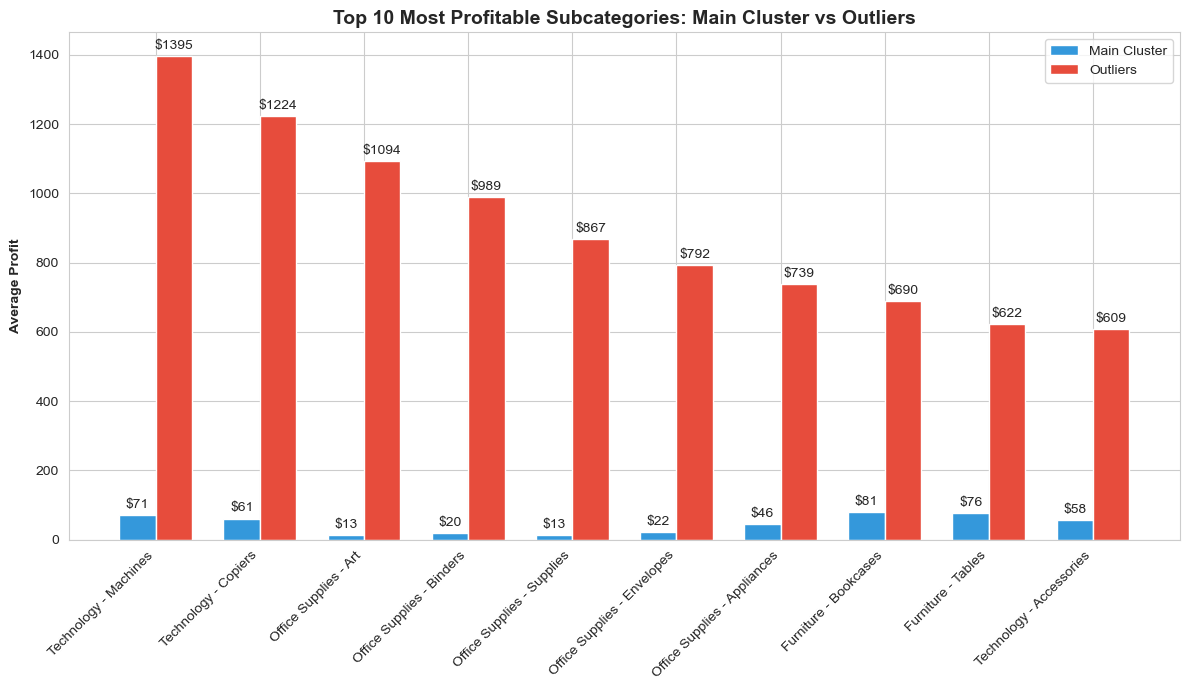

In [22]:
# Function to analyze profitability by category and subcategory
def category_subcategory_profit_analysis(main_df, outlier_df):
    # Make copies to prevent modifying original data
    main_df = main_df.copy()
    outlier_df = outlier_df.copy()
    
    # Ensure there are no missing category values
    main_df = main_df.dropna(subset=['Category', 'Sub Category'])
    outlier_df = outlier_df.dropna(subset=['Category', 'Sub Category'])
    
    # Group by Category and Sub Category and calculate metrics
    main_profit = main_df.groupby(['Category', 'Sub Category']).agg({
        'Profit': 'mean',
        'Order Id': 'count'
    }).reset_index()
    
    outlier_profit = outlier_df.groupby(['Category', 'Sub Category']).agg({
        'Profit': 'mean',
        'Order Id': 'count'
    }).reset_index()
    
    # Rename columns for clarity
    main_profit.rename(columns={
        'Profit': 'Main Cluster Avg Profit',
        'Order Id': 'Main Cluster Order Count'
    }, inplace=True)
    
    outlier_profit.rename(columns={
        'Profit': 'Outliers Avg Profit',
        'Order Id': 'Outliers Order Count'
    }, inplace=True)
    
    # Merge the two dataframes on Category and Sub Category
    merged_profit = pd.merge(
        main_profit, 
        outlier_profit, 
        on=['Category', 'Sub Category'], 
        how='outer'
    ).fillna(0)
    
    # Calculate profit difference and ratio
    merged_profit['Profit Difference'] = merged_profit['Outliers Avg Profit'] - merged_profit['Main Cluster Avg Profit']
    merged_profit['Profit Ratio'] = merged_profit.apply(
        lambda x: 0 if x['Main Cluster Avg Profit'] == 0 
        else x['Outliers Avg Profit'] / x['Main Cluster Avg Profit'],
        axis=1
    )
    
    # Sort by Outliers Avg Profit descending
    merged_profit = merged_profit.sort_values(by='Outliers Avg Profit', ascending=False)
    
    return merged_profit

# Execute the analysis
category_profit_comparison = category_subcategory_profit_analysis(main_cluster, outliers)

# Display top 10 subcategories by outlier profit
print("Top 10 Subcategories by Outlier Average Profit:")
print(category_profit_comparison.head(10))

# Visualize the top 10 subcategories
plt.figure(figsize=(14, 8))
sns.set_style("whitegrid")

# Get top 10 subcategories
top10 = category_profit_comparison.head(10)

# Create concatenated category-subcategory labels
top10['Cat-SubCat'] = top10['Category'] + ' - ' + top10['Sub Category']

# Plot the comparison
x = np.arange(len(top10))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 7))
main_bars = ax.bar(x - width/2, top10['Main Cluster Avg Profit'], width, label='Main Cluster', color='#3498db')
outlier_bars = ax.bar(x + width/2, top10['Outliers Avg Profit'], width, label='Outliers', color='#e74c3c')

# Add labels, title and legend
ax.set_ylabel('Average Profit', fontweight='bold')
ax.set_title('Top 10 Most Profitable Subcategories: Main Cluster vs Outliers', fontweight='bold', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(top10['Cat-SubCat'], rotation=45, ha='right')
ax.legend()

# Add value labels on bars
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'${height:.0f}',
                   xy=(bar.get_x() + bar.get_width() / 2, height),
                   xytext=(0, 3),  # 3 points vertical offset
                   textcoords="offset points",
                   ha='center', va='bottom')

add_labels(main_bars)
add_labels(outlier_bars)

plt.tight_layout()
plt.savefig('top_subcategories.png', dpi=300)
plt.show()



1. Tech Dominance in Outliers:
   - Machines (1,395/order) & Copiers (1,224/order) = top absolute profits

2. Office Supplies' Hidden Potential: 
   - Binders (50.7×) & Supplies (64.6×) = best multipliers  
   - Contrast: Despite the office supplies industry’s low average net margin (3.4%), outliers here show disproportionate profitability – likely from bulk orders or premium pricing.

3. Furniture Consistency  
   - Bookcases/Tables: Consistent pricing (8× gaps). The show the smallest profit ratios (8.5× and 8.1× respectively), suggesting more consistent pricing across value segments.
   - Furniture’s average net margin (~5.15%) aligns with stable outlier ratios, suggesting predictable pricing strategies.





<!-- Technology Products Dominate High-Value Sales: Technology subcategories (Machines, Copiers) lead with the highest absolute outlier profits ($1394 and $1223 respectively).

Office Supplies Show Highest Profit Ratios: While not the highest absolute profit, Office Supplies subcategories show the most dramatic profit differences:

Art: 82.6× higher profit in outliers

Supplies: 64.6× higher

Binders: 50.7× higher

Furniture Has Smallest Gaps: Bookcases and Tables show the smallest profit ratios (8.5× and 8.1× respectively), suggesting more consistent pricing across value segments. -->

##  Loss Analysis for Main Cluster

In [23]:
def profit_margin_discount_correlation_only(main_df, outlier_df):
    """
    Calculate correlation between discount percent and profit margin for main cluster and outliers.
    Returns a nicely formatted correlation matrix without visualizations.
    
    Parameters:
    -----------
    main_df : DataFrame
        The main cluster data
    outlier_df : DataFrame
        The outlier data
    
    Returns:
    --------
    DataFrame
        Correlation between discount percent and profit margin by category and cluster
    """
    # Make copies to prevent modifying original dataframes
    main_df = main_df.copy()
    outlier_df = outlier_df.copy()
    
    # Calculate profit margin
    main_df['Profit_Margin'] = (main_df['Profit'] / (main_df['List Price'] * main_df['Quantity'])) * 100
    outlier_df['Profit_Margin'] = (outlier_df['Profit'] / (outlier_df['List Price'] * outlier_df['Quantity'])) * 100
    
    # Combine the data for comparison
    main_df['Cluster'] = 'Main Cluster'
    outlier_df['Cluster'] = 'Outliers'
    combined_df = pd.concat([main_df, outlier_df])
    
    # Calculate correlation between discount and profit margin
    corr = combined_df.groupby(['Category', 'Cluster'])[['Discount Percent', 'Profit_Margin']].corr()
    corr_reset = corr.reset_index()
    
    # Filter to get only Discount Percent's correlation with Profit Margin
    corr_filtered = corr_reset[corr_reset['level_2'] == 'Profit_Margin']
    
    # Extract relevant columns
    corr_filtered = corr_filtered[['Category', 'Cluster', 'Discount Percent']]
    corr_filtered = corr_filtered.rename(columns={'Discount Percent': 'Correlation'})
    
    # Create a nicely formatted pivot table
    corr_pivot = corr_filtered.pivot(index='Category', columns='Cluster', values='Correlation')
    
    # Display the correlation matrix with formatting
    display(corr_pivot.style.format("{:.4f}")
           .set_caption("Correlation between Discount Percent and Profit Margin")
           .background_gradient(cmap='RdBu_r', vmin=-1, vmax=1))
    
    return corr_pivot

# Run the analysis (assuming main_cluster and outliers are defined)
correlation_results = profit_margin_discount_correlation_only(main_cluster, outliers)


Cluster,Main Cluster,Outliers
Category,,
Furniture,-0.1720,-0.2484
Office Supplies,-0.1361,-0.2207
Technology,-0.1376,-0.2239


* All correlations are negative, confirming that higher discounts reduce profit margins across all products, but the effect is considerably stronger for outliers (premium products).

* The outlier cluster shows substantially stronger negative correlations (-0.22 to -0.25) compared to the main cluster (-0.13 to -0.17), indicating that high-value products experience approximately 1.4 – 1.6X greater profit erosion when discounted than regular products do.

* Most vulnerable are furnitures in both clusters, with the strongest negative correlations (-0.1720 in main cluster, -0.2484 in outliers), suggesting that discount strategies should be particularly careful with this category.
* Least vulnerable: Office Supplies

# More Insights


C:\Users\KIIT\AppData\Local\Temp\ipykernel_5580\2937725809.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Profit_Margin'] = (df['Profit'] / (df['List Price'] * df['Quantity'])) * 100


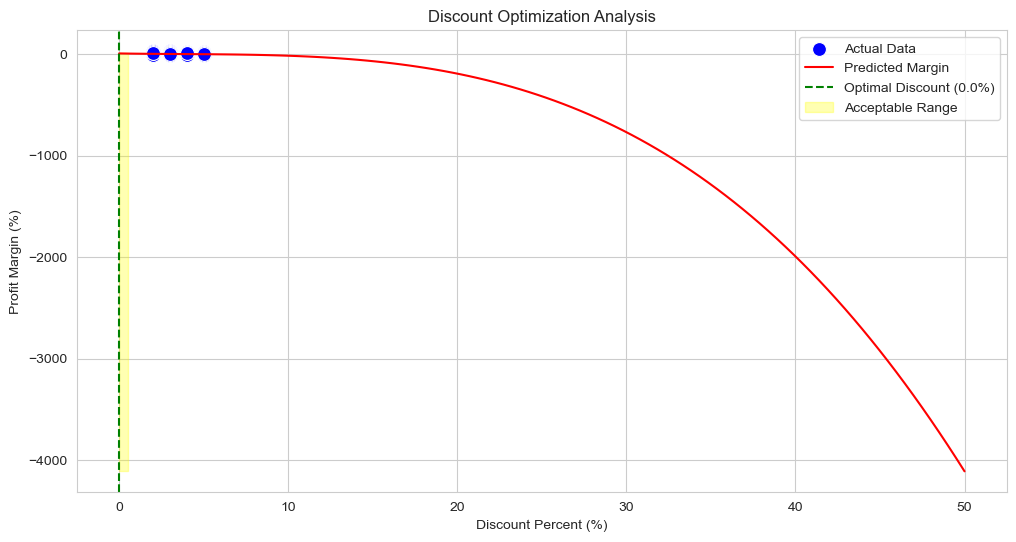

Optimal Discount: 0.0%
Acceptable Range: 0.0% - 0.5%


In [24]:
# Optimize Discount
import statsmodels.api as sm

def optimize_discount(df, min_discount=0, max_discount=50, margin_threshold=0.2):
    """
    Analyzes discount impact on profit margins and recommends optimal discount range.
    
    Parameters:
    df : DataFrame with columns: ['Discount Percent', 'Profit', 'List Price', 'Quantity']
    min/max_discount : Range to analyze
    margin_threshold : Maximum acceptable margin erosion (20% default)
    """
    
    # Calculate profit margin
    df['Profit_Margin'] = (df['Profit'] / (df['List Price'] * df['Quantity'])) * 100
    
    # Filter discounts in specified range
    discount_df = df[(df['Discount Percent'] >= min_discount) & 
                    (df['Discount Percent'] <= max_discount)].copy()
    
    # Add polynomial terms for nonlinear relationships
    discount_df['Discount_Squared'] = discount_df['Discount Percent']**2
    discount_df['Discount_Cubed'] = discount_df['Discount Percent']**3
    
    # Prepare regression data
    X = discount_df[['Discount Percent', 'Discount_Squared', 'Discount_Cubed']]
    X = sm.add_constant(X)
    y = discount_df['Profit_Margin']
    
    # Fit polynomial regression model
    model = sm.OLS(y, X).fit()
    
    # Generate predictions
    discount_range = np.linspace(min_discount, max_discount, 100)
    X_pred = pd.DataFrame({
        'Discount Percent': discount_range,
        'Discount_Squared': discount_range**2,
        'Discount_Cubed': discount_range**3
    })
    X_pred = sm.add_constant(X_pred)
    predicted_margin = model.predict(X_pred)
    
    # Find optimal discount (max margin preservation)
    optimal_idx = np.argmax(predicted_margin)
    optimal_discount = discount_range[optimal_idx]
    
    # Find acceptable discount range (within threshold)
    max_margin = predicted_margin.max()
    acceptable_discounts = discount_range[predicted_margin >= (1 - margin_threshold)*max_margin]
    
    # Visualization
    plt.figure(figsize=(12, 6))
    sns.scatterplot(x='Discount Percent', y='Profit_Margin', data=discount_df, 
                    color='blue', s=100, label='Actual Data')
    plt.plot(discount_range, predicted_margin, color='red', 
             label='Predicted Margin')
    plt.axvline(x=optimal_discount, color='green', linestyle='--', 
                label=f'Optimal Discount ({optimal_discount:.1f}%)')
    plt.fill_betweenx(y=predicted_margin, x1=acceptable_discounts.min(), 
                      x2=acceptable_discounts.max(), color='yellow', alpha=0.3,
                      label='Acceptable Range')
    plt.xlabel('Discount Percent (%)')
    plt.ylabel('Profit Margin (%)')
    plt.title('Discount Optimization Analysis')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    # Print recommendations
    print(f"Optimal Discount: {optimal_discount:.1f}%")
    print(f"Acceptable Range: {acceptable_discounts.min():.1f}% - {acceptable_discounts.max():.1f}%")
    
    return model, optimal_discount

# Usage with your dataset (assuming main_cluster is loaded)
model, optimal = optimize_discount(main_cluster)


In [25]:
# Which product categories and sub-categories are most profitable?


def analyze_profitability(df, cluster_name):
    """Analyze profitability at category and sub-category level."""
    # Category analysis
    category_profit = df.groupby('Category').agg(
        Avg_Profit=('Profit', 'mean'),
        Total_Profit=('Profit', 'sum'),
        Order_Count=('Order Id', 'count')
    ).sort_values('Total_Profit', ascending=False)
    
    # Sub-category analysis
    subcat_profit = df.groupby(['Category', 'Sub Category']).agg(
        Avg_Profit=('Profit', 'mean'),
        Total_Profit=('Profit', 'sum'),
        Order_Count=('Order Id', 'count')
    ).sort_values('Total_Profit', ascending=False)
    
    return category_profit, subcat_profit

def format_currency(df):
    """Format currency columns with dollar signs."""
    return df.style.format({
        'Avg_Profit': '${:,.2f}',
        'Total_Profit': '${:,.2f}'
    })

# Analyze main cluster
main_cat, main_subcat = analyze_profitability(main_cluster, "Main Cluster")

# Analyze outliers
outlier_cat, outlier_subcat = analyze_profitability(outliers, "Outliers")

# Display results
print("Main Cluster - Category Profitability")
display(format_currency(main_cat.head()))
print("\nMain Cluster - Top Subcategories")
display(format_currency(main_subcat.head()))

print("\n\nOutliers - Category Profitability")
display(format_currency(outlier_cat.head()))
print("\nOutliers - Top Subcategories")
display(format_currency(outlier_subcat.head()))


Main Cluster - Category Profitability


,Avg_Profit,Total_Profit,Order_Count
Category,,,
Office Supplies,$24.62,"$130,198.10",5289
Furniture,$53.16,"$89,101.40",1676
Technology,$57.58,"$84,235.00",1463



Main Cluster - Top Subcategories




Outliers - Category Profitability


,Avg_Profit,Total_Profit,Order_Count
Category,,,
Technology,$794.32,"$295,485.70",372
Furniture,$605.44,"$253,681.00",419
Office Supplies,$698.61,"$187,227.00",268



Outliers - Top Subcategories


1. Technology Drives Premium Profits, Office Supplies Dominate Volume

Outliers: Technology accounts for 41% of total outlier profit (295K) with Machines generating $1,395/order.

Main Cluster: Office Supplies contribute 45% of profit (130K) through high volume (5,289 orders) despite low margins (24.62/order).

2. Furniture Subcategories Show Premium Potential

Outlier Chairs/Tables: Deliver 2.4× higher average profit (588–622) vs. main cluster chairs (79.76).

Main Cluster Chairs: Most profitable furniture subcategory (79.76 avg), but volume lags Office Supplies.

3. High-Value Binders Defy Expectations

Outlier Binders: Generate 989.11/order (vs. 19.51 in main cluster), suggesting premium/large-format products.



In [26]:
df.shape

(9487, 16)

In [27]:
# 1. Calculate discount amount per unit
df['Discount_Amount'] = df['List Price'] * (df['Discount Percent'] / 100)

# 2. Calculate profit per unit after discount and cost
df['Unit_Profit'] = (df['List Price'] - df['Discount_Amount']) - df['cost price']

# 3. Calculate total profit for the order
df['Total_Profit'] = df['Unit_Profit'] * df['Quantity']

# Verify the new columns
print("\nFirst 5 rows with profit calculations:")
print(df[['List Price', 'Discount Percent', 'cost price', 'Quantity', 
          'Discount_Amount', 'Unit_Profit', 'Total_Profit']].head())

# Check for negative profits (data quality check)
negative_profits = df[df['Total_Profit'] < 0]
print(f"\nOrders with negative profit: {len(negative_profits)}")



First 5 rows with profit calculations:
   List Price  Discount Percent  cost price  Quantity  Discount_Amount  \
0         260                 2         240         2              5.2   
1         730                 3         600         3             21.9   
2          10                 5          10         2              0.5   
3         960                 2         780         5             19.2   
4          20                 5          20         2              1.0   

   Unit_Profit  Total_Profit  
0         14.8          29.6  
1        108.1         324.3  
2         -0.5          -1.0  
3        160.8         804.0  
4         -1.0          -2.0  

Orders with negative profit: 3997


Orders with negative profit: 3997
Orders with positive profit: 5490


C:\Users\KIIT\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\KIIT\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\KIIT\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


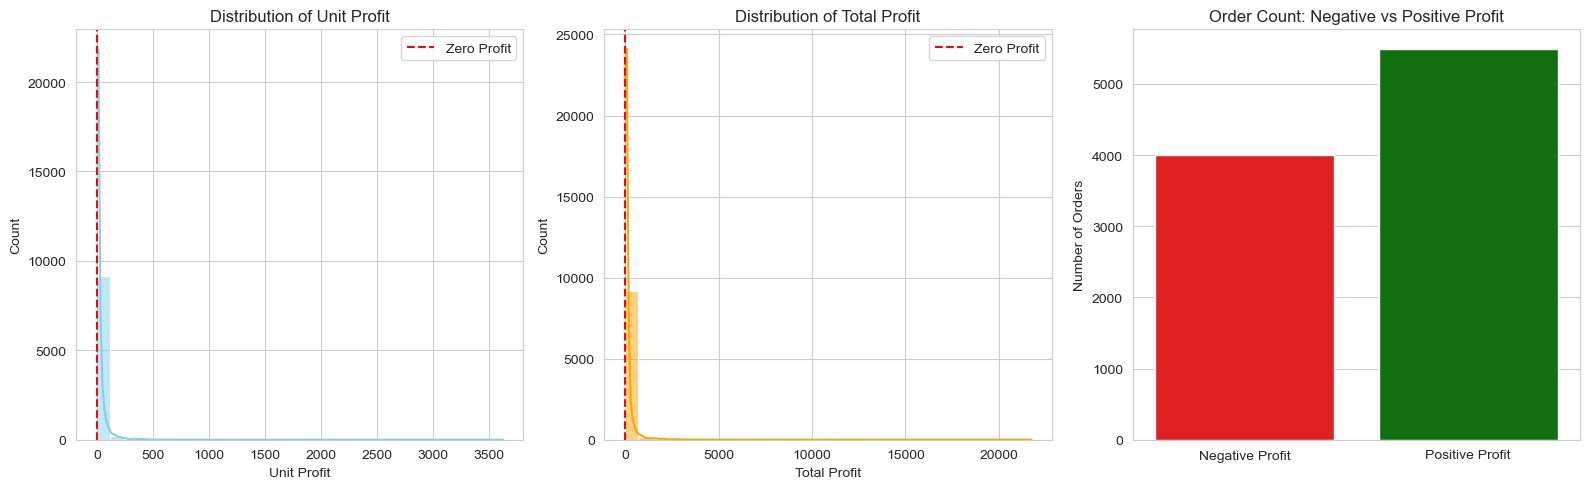

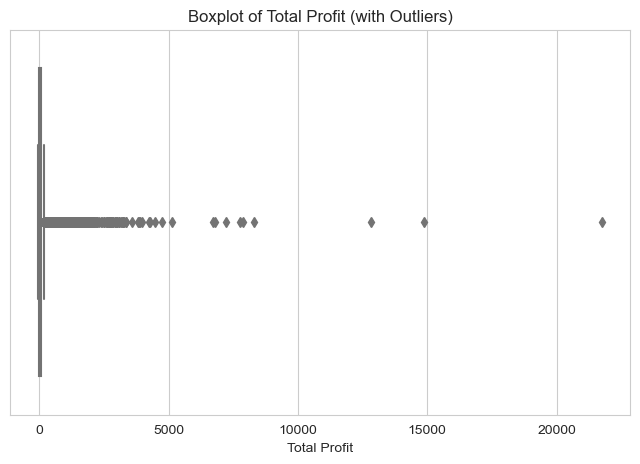

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Example: for the whole dataset
df = df.copy()

# 1. Calculate discount amount per unit
df['Discount_Amount'] = df['List Price'] * (df['Discount Percent'] / 100)

# 2. Calculate profit per unit after discount and cost
df['Unit_Profit'] = (df['List Price'] - df['Discount_Amount']) - df['cost price']

# 3. Calculate total profit for the order
df['Total_Profit'] = df['Unit_Profit'] * df['Quantity']

# 4. Check for negative profits
negative_profits = df[df['Total_Profit'] < 0]
positive_profits = df[df['Total_Profit'] >= 0]

print(f"Orders with negative profit: {len(negative_profits)}")
print(f"Orders with positive profit: {len(positive_profits)}")

# 5. Visualizations

plt.figure(figsize=(16, 5))

# Histogram of Unit Profit
plt.subplot(1, 3, 1)
sns.histplot(df['Unit_Profit'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Unit Profit')
plt.xlabel('Unit Profit')
plt.axvline(0, color='red', linestyle='--', label='Zero Profit')
plt.legend()

# Histogram of Total Profit
plt.subplot(1, 3, 2)
sns.histplot(df['Total_Profit'], bins=30, kde=True, color='orange')
plt.title('Distribution of Total Profit')
plt.xlabel('Total Profit')
plt.axvline(0, color='red', linestyle='--', label='Zero Profit')
plt.legend()

# Bar plot: Negative vs Positive Profit Orders
plt.subplot(1, 3, 3)
sns.barplot(
    x=['Negative Profit', 'Positive Profit'],
    y=[len(negative_profits), len(positive_profits)],
    palette=['red', 'green']
)
plt.title('Order Count: Negative vs Positive Profit')
plt.ylabel('Number of Orders')

plt.tight_layout()
plt.show()

# Optional: Boxplot to show profit outliers
plt.figure(figsize=(8, 5))
sns.boxplot(x='Total_Profit', data=df, color='lightgreen')
plt.title('Boxplot of Total Profit (with Outliers)')
plt.xlabel('Total Profit')
plt.show()


* 3,997 out of 9,487  orders (about 42% of all transactions result in losses rather than profits, creating a substantial drag on overall margins).

* Orders with low prices and high discounts or where cost price ≈ list price.

* Margin Vulnerability: When nearly half of all transactions lose money, the business becomes highly dependent on its most profitable customers/segments

In [29]:
# Calculate Profit (using your confirmed column names)
df['Discount_Amount'] = df['List Price'] * (df['Discount Percent'] / 100)
df['Unit_Profit'] = (df['List Price'] - df['Discount_Amount']) - df['cost price']
df['Total_Profit'] = df['Unit_Profit'] * df['Quantity']

# 1. Top 10 Profit Generating Products
top10_profit = df.groupby('Product Id').agg(
    Total_Profit=('Total_Profit', 'sum'),
    Total_Quantity=('Quantity', 'sum'),
    Avg_Profit_Per_Unit=('Total_Profit', 'mean')
).sort_values('Total_Profit', ascending=False).head(10)

# 2. Top 3 Products by Quantity in Each Region
def top3_products(group):
    return group.nlargest(3, 'Total_Quantity')

region_top = df.groupby(['Region', 'Product Id']).agg(
    Total_Quantity=('Quantity', 'sum')
).reset_index().groupby('Region').apply(top3_products)

# Display results
print("Top 10 Highest Profit Generating Products:")
display(top10_profit.style.format({
    'Total_Profit': '${:,.2f}',
    'Avg_Profit_Per_Unit': '${:,.2f}'
}))

print("\nTop 3 Products by Quantity in Each Region:")
display(region_top.style.format({'Total_Quantity': '{:,}'}))

Top 10 Highest Profit Generating Products:


C:\Users\KIIT\AppData\Local\Temp\ipykernel_5580\215615593.py:19: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ).reset_index().groupby('Region').apply(top3_products)


,Total_Profit,Total_Quantity,Avg_Profit_Per_Unit
Product Id,,,
TEC-CO-10004722,"$24,816.00",20,"$4,963.20"
TEC-MA-10002412,"$21,746.40",6,"$21,746.40"
OFF-BI-10000545,"$17,867.70",48,"$1,985.30"
TEC-CO-10001449,"$15,948.00",38,"$1,993.50"
FUR-CH-10002024,"$13,930.70",39,"$1,741.34"
OFF-BI-10003527,"$12,792.90",31,"$1,279.29"
TEC-PH-10001459,"$11,481.90",39,"$1,913.65"
TEC-MA-10000822,"$10,102.30",18,"$2,525.58"
FUR-TA-10000198,"$10,015.10",27,"$2,003.02"



Top 3 Products by Quantity in Each Region:


In [30]:

# Calculate effective price and profit
df['Effective_Price'] = df['List Price'] * (1 - df['Discount Percent']/100)
df['Unit_Loss'] = df['cost price'] - df['Effective_Price']
df['Total_Loss'] = df['Unit_Loss'] * df['Quantity']

# Identify loss-making products
loss_products = df[df['Unit_Loss'] > 0]

# Aggregate by product and category
loss_analysis = loss_products.groupby(['Product Id', 'Category', 'Sub Category']).agg(
    Total_Orders=('Order Id', 'count'),
    Total_Loss_Orders=('Order Id', 'count'),
    Avg_Cost=('cost price', 'mean'),
    Avg_Effective_Price=('Effective_Price', 'mean'),
    Total_Quantity=('Quantity', 'sum'),
    Total_Loss_Amount=('Total_Loss', 'sum')
)

# Get total orders per product from original data
total_orders = df.groupby(['Product Id', 'Category', 'Sub Category'])['Order Id'].count()

# Calculate loss percentage
loss_analysis['Pct_Loss'] = (loss_analysis['Total_Loss_Orders'] / total_orders * 100).round(2)

# Filter consistently problematic products (appearing in 90%+ orders at loss)
consistent_loss = loss_analysis[loss_analysis['Pct_Loss'] >= 90].sort_values(
    ['Pct_Loss', 'Total_Loss_Amount'], ascending=[False, False]
).head(10)

# Format results
consistent_loss_formatted = consistent_loss.reset_index()
consistent_loss_formatted[['Avg_Cost', 'Avg_Effective_Price', 'Total_Loss_Amount']] = \
consistent_loss_formatted[['Avg_Cost', 'Avg_Effective_Price', 'Total_Loss_Amount']].applymap(
    lambda x: f"${abs(x):,.2f}"
)

consistent_loss_formatted.style.hide(axis="index").set_caption(
    "Products Consistently Sold at Loss (Category/Subcategory Level)"
)


C:\Users\KIIT\AppData\Local\Temp\ipykernel_5580\1261651572.py:33: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  consistent_loss_formatted[['Avg_Cost', 'Avg_Effective_Price', 'Total_Loss_Amount']].applymap(


Product Id,Category,Sub Category,Total_Orders,Total_Loss_Orders,Avg_Cost,Avg_Effective_Price,Total_Quantity,Total_Loss_Amount,Pct_Loss
OFF-FA-10002280,Office Supplies,Fasteners,10,10,$26.00,$25.18,47,$48.20,100.000000
OFF-BI-10002799,Office Supplies,Binders,5,5,$24.00,$22.84,35,$44.50,100.000000
OFF-PA-10000143,Office Supplies,Paper,6,6,$26.67,$25.63,29,$39.50,100.000000
OFF-AR-10003631,Office Supplies,Art,4,4,$27.50,$26.60,30,$37.00,100.000000
OFF-BI-10003712,Office Supplies,Binders,7,7,$18.57,$17.81,36,$35.70,100.000000
OFF-BI-10003460,Office Supplies,Binders,7,7,$18.57,$17.77,33,$34.90,100.000000
OFF-FA-10000624,Office Supplies,Fasteners,7,7,$20.00,$19.29,38,$33.20,100.000000
OFF-BI-10003429,Office Supplies,Binders,7,7,$21.43,$20.61,36,$33.10,100.000000
OFF-SU-10003567,Office Supplies,Supplies,4,4,$35.00,$33.58,17,$33.10,100.000000
OFF-PA-10002709,Office Supplies,Paper,2,2,$45.00,$43.40,16,$32.80,100.000000


* All top loss-making products are Office Supplies, suggesting this category needs urgent review.
* Subcategories affected: Fasteners, Binders, Paper, Art, Supplies.

* Small Margins, Big Losses: Price gaps are tiny:

    - Fasteners: 26.00 (cost) vs. 25.18 (price) → $0.82/unit loss

    - Binders: 24.00 vs. 22.84 → 1.16/unit loss
* High volume compounds losses:

    - Fasteners: 47 units sold → 48.20 total loss

    - Binders: 35 units → 44.50 loss



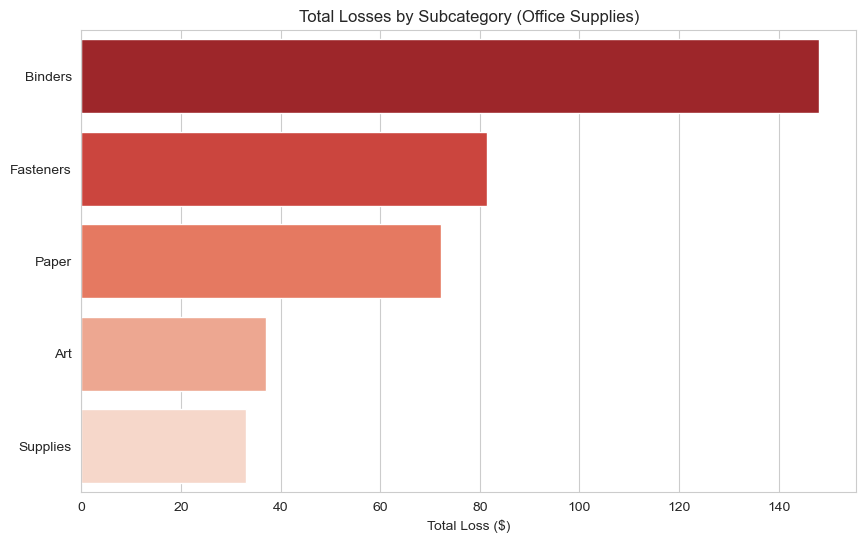

In [31]:
# 1. Calculate effective price and profit
df['Effective_Price'] = df['List Price'] * (1 - df['Discount Percent']/100)
df['Unit_Loss'] = df['cost price'] - df['Effective_Price']
df['Total_Loss'] = df['Unit_Loss'] * df['Quantity']

# 2. Identify loss-making products
loss_products = df[df['Unit_Loss'] > 0]

# 3. Aggregate by product and category
loss_analysis = loss_products.groupby(['Product Id', 'Category', 'Sub Category']).agg(
    Total_Orders=('Order Id', 'count'),
    Total_Loss_Orders=('Order Id', 'count'),
    Avg_Cost=('cost price', 'mean'),
    Avg_Effective_Price=('Effective_Price', 'mean'),
    Total_Quantity=('Quantity', 'sum'),
    Total_Loss_Amount=('Total_Loss', 'sum')
)

# 4. Get total orders per product
total_orders = df.groupby(['Product Id', 'Category', 'Sub Category'])['Order Id'].count()

# 5. Calculate loss percentage
loss_analysis['Pct_Loss'] = (loss_analysis['Total_Loss_Orders'] / total_orders * 100).round(2)

# 6. Filter problematic products
consistent_loss = loss_analysis[loss_analysis['Pct_Loss'] >= 90].sort_values(
    ['Pct_Loss', 'Total_Loss_Amount'], ascending=[False, False]
).head(10)

# 7. Format results (FIXED)
consistent_loss_formatted = consistent_loss.reset_index()
consistent_loss_formatted['Total_Loss_Amount_Num'] = consistent_loss_formatted['Total_Loss_Amount']  # Keep numeric

# Format currency columns individually
consistent_loss_formatted['Avg_Cost'] = consistent_loss_formatted['Avg_Cost'].map(lambda x: f"${x:,.2f}")
consistent_loss_formatted['Avg_Effective_Price'] = consistent_loss_formatted['Avg_Effective_Price'].map(lambda x: f"${x:,.2f}")
consistent_loss_formatted['Total_Loss_Amount'] = consistent_loss_formatted['Total_Loss_Amount_Num'].map(lambda x: f"${x:,.2f}")

# 8. Visualization (FIXED)
loss_subcat = consistent_loss_formatted.groupby('Sub Category')['Total_Loss_Amount_Num'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(
    x=loss_subcat.values,
    y=loss_subcat.index,
    palette='Reds_r',
    orient='h'
)
plt.title('Total Losses by Subcategory (Office Supplies)')
plt.xlabel('Total Loss ($)')
plt.ylabel('')
plt.show()


In [32]:
# Subcategories in Office Supplies: ['Labels' 'Storage' 'Art' 'Binders' 'Appliances' 'Paper' 'Envelopes'
#  'Fasteners' 'Supplies']

* Binders are the biggest loss drivers (148.20 total loss)

* Fasteners and Paper follow with 81.40 and 72.30 losses respectively

* All problematic products are in Office Supplies category

* Small per-unit losses (0.82-1.16) accumulate through high sales volumes

In [ ]:
# make github of this , link it in resume